In [69]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import seaborn as sns
import squidpy as sq
from spatialdata_io import xenium


In [63]:
color_map = sns.dark_palette("#69d", reverse=True, as_cmap=True)

In [60]:
output_dir = Path("/Volumes/sep22/home/wet_lab/_Experiments/009_ST_Xenium/")
output_dir = output_dir / "KM_ILC_figs_V2"
output_dir.mkdir(exist_ok=True, parents=True)

In [37]:
adata = sc.read_h5ad("/Volumes/phenotypingsputumasthmaticsaurorawellcomea1/live/Sara_Patti/009_ST_Xenium/data/out_data/adata/all_samples.h5ad")

In [38]:
adata.obs["ROI"].unique()

['COPD_R009_V3', 'PM08_159_A1', 'COPD_R010_V2', 'COPD_R011_V1', 'COPD_R035_V2', ..., 'COPD_R035_V3', 'IPF_RBH_16', 'COPD_R035_V1', 'COPD_R039_V1', 'IPF_RBH_19']
Length: 12
Categories (12, object): ['COPD_R003_V3', 'COPD_R009_V3', 'COPD_R010_V2', 'COPD_R011_V1', ..., 'IPF_RBH_2', 'IPF_RBH_16', 'IPF_RBH_19', 'PM08_159_A1']

In [41]:
# Sample lists
ROI_list = ["PM08_159_A1", "COPD_R011_V1", "COPD_R035_V1", "COPD_R039_V1"]
adata._inplace_subset_obs(adata.obs["ROI"].isin(ROI_list))

In [42]:
adata.obs["ROI"].unique()

['PM08_159_A1', 'COPD_R011_V1', 'COPD_R035_V1', 'COPD_R039_V1']
Categories (4, object): ['COPD_R011_V1', 'COPD_R035_V1', 'COPD_R039_V1', 'PM08_159_A1']

# QC data

In [43]:
sc.pp.filter_cells(adata, min_counts=10)
sc.pp.filter_genes(adata, min_cells=5)

In [44]:
adata = adata[(adata.obs["cell_area"] >= 50) & (adata.obs["cell_area"] <= 1000), :,].copy()

In [45]:
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, inplace=True)
sc.pp.log1p(adata)
sc.pp.scale(adata, max_value=10)

/Users/sarapatti/miniforge3/envs/xenium_5k/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


# Dimensionality reduction

In [46]:
sc.pp.pca(adata)
sc.pp.neighbors(adata)

In [47]:
sc.tl.umap(adata)
sc.tl.leiden(adata)

In [ ]:
# adata.write_h5ad(output_dir / "KM_ILC_adata.h5ad")

In [ ]:
# adata = sc.read_h5ad(output_dir / "KM_ILC_adata.h5ad")

# Data visualization

In [57]:
fig = sc.pl.umap(
    adata,
    color=[
        "total_counts",
        "leiden",
        "ROI",
    ],
    wspace=0.4,
    show=False,
    return_fig=True
)
fig.savefig(output_dir / "UMAP_ILCs.png", bbox_inches='tight', dpi=300)
plt.close()

In [65]:
adata_roi = adata[adata.obs["ROI"] == "COPD_R011_V1", :].copy()

In [79]:
cmap_2 = sns.color_palette(palette='PuBu', as_cmap=True)

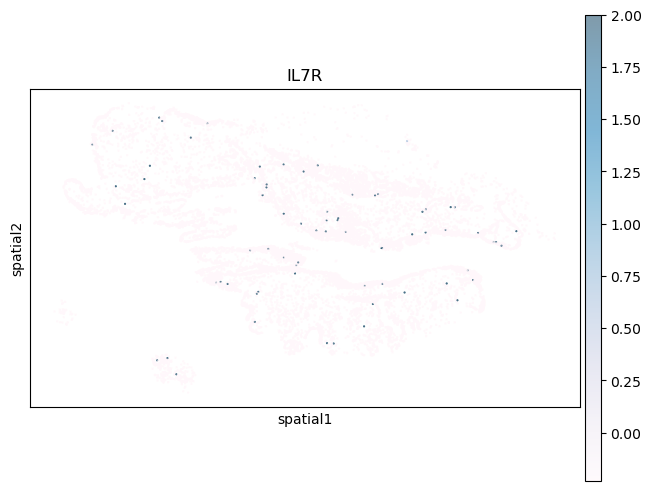

In [80]:
sq.pl.spatial_scatter(
                adata_roi,
                library_id="spatial",
                shape=None,
                color="IL7R",
                cmap=cmap_2,
                size=1,
                alpha=0.5,
                vmax=2,
                wspace=0.4  
            )

In [49]:
ILC_list = ["IL7R", "KLRB1", "GATA3", "TBX21", "RORC", "IFNG", "IL17A", "CD3D", "CD3E"]

In [50]:
for gene in ILC_list:
    if gene in adata.var_names:
        sc.pl.umap(
            adata,
            color=gene,
            wspace=0.4,
            color_map=color_map,
            vmax=6,
            size=10,
            show=False  # Don't display, just create the figure
        )
        plt.savefig(output_dir / f"UMAP_{gene}_ILCs.png", bbox_inches='tight', dpi=300)
        plt.close()

In [64]:
for ROI in ROI_list:
    adata_roi = adata[adata.obs["ROI"] == ROI, :].copy()
    print(f"Processing ROI: {ROI} with {adata_roi.n_obs} cells.")
    for gene in ILC_list:
        if gene in adata_roi.var_names:
            sq.pl.spatial_scatter(
                adata_roi,
                library_id="spatial",
                shape=None,
                color=gene,
                cmap=color_map,
                size=1,
                alpha=0.5,
                vmax=5,
                wspace=0.4  
            )
            plt.savefig(output_dir / f"spatial_{gene}_{ROI}_ILCs.png", bbox_inches='tight', dpi=300)
            plt.close()

Processing ROI: PM08_159_A1 with 54689 cells.
Processing ROI: COPD_R011_V1 with 10008 cells.
Processing ROI: COPD_R035_V1 with 11301 cells.
Processing ROI: COPD_R039_V1 with 7937 cells.


In [59]:
for ROI in ROI_list:
    adata_roi = adata[adata.obs["ROI"] == ROI, :].copy()
    sq.pl.spatial_scatter(
        adata_roi,
        library_id="spatial",
        shape=None,
        color="leiden",
        cmap=color_map,
        size=1,
        alpha=0.5,
        wspace=0.4,
    )
    plt.savefig(output_dir / f"spatial_leiden_{ROI}_ILCs.png", bbox_inches='tight', dpi=300)
    plt.close()

/Users/sarapatti/miniforge3/envs/xenium_5k/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/Users/sarapatti/miniforge3/envs/xenium_5k/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/Users/sarapatti/miniforge3/envs/xenium_5k/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/Users/sarapatti/miniforge3/envs/xenium_5k/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
